# 2 — Preprocessing GPS MAID untuk OD Analysis Ring Road Utara

Pipeline preprocessing data MAID GPS untuk analisis Origin-Destination (OD)
6 simpang RRU. Mengikuti taksonomi 4-pilar dari Li et al. (2025) — *Trajectory
Data Preprocessing: Methods and Models* — dengan adaptasi untuk karakter MAID
(event-driven sampling, multi-app source, sensor fusion bursts).

## Stage overview
- **Stage 0** — Setup jaringan jalan RRU (OSMnx).
- **Stage 1a** — Bounding box + temporal filter, drop singleton MAID.
- **Stage 1b** — Snap candidate edge (R-tree), drop singleton MAID.
- **Stage 1c** — Bilocation handling (collapse spread kecil), drop singleton MAID.
  drop short trips.

> Setelah setiap operasi destruktif: re-apply *invariant restoration*
> (`drop_singleton_maids`, `drop_short_trips`) untuk menjaga konsistensi pipeline.


## Setup

In [3]:
# Standard library
from collections import Counter
from pathlib import Path

# Third-party
import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import polars as pl
import seaborn as sns
import shapely
from folium.plugins import MeasureControl
from pyproj import Transformer
from shapely.strtree import STRtree


### Konstanta & path

In [4]:
# ---- I/O paths ----
INPUT_PARQUET = Path("./processed-data/all_gps_data_no_dup.parquet")
CACHE_DIR = Path("./cache")
PROCESSED_DIR = Path("./processed-data")

OUTPUT_BBOX = PROCESSED_DIR / "output_bbox.parquet"
OUTPUT_CANDIDATES = PROCESSED_DIR / "gps_rru_candidates.parquet"
OUTPUT_COLLAPSED = PROCESSED_DIR / "gps_rru_collapsed.parquet"
OUTPUT_TRIPS = PROCESSED_DIR / "gps_rru_trips.parquet"
OUTPUT_FINAL = PROCESSED_DIR / "gps_rru_final.parquet"

CACHE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ---- Spatial scope ----
# Pre-filter bounding box (WGS84) — kotak pembungkus area Ring Road Utara
LON_MIN, LON_MAX = 110.342299, 110.433240
LAT_MIN, LAT_MAX = -7.767411, -7.742002

EPSG_WGS84 = 4326
EPSG_UTM49S = 32749  # CRS metrik Yogyakarta — wajib untuk distance dalam meter

MAX_DIST_METERS = 50  # buffer ke jaringan RRU

# ---- Temporal scope ----
# Hanya bulan Februari 2022 (epoch seconds)
TS_START = 1643648400
TS_END = 1646067599

# ---- Stage 2 (SPD) thresholds ----
SPD_DIST_THRESHOLD_M = 100.0       # radius klaster stay point (Zheng 2011)
SPD_TIME_THRESHOLD_MIN = 20.0      # durasi minimal untuk qualify sebagai stay point
MIN_PINGS_PER_TRIP = 3             # trip < ini di-drop (HMM butuh >= 3 untuk heading)

# ---- Reference points: 6 simpang RRU ----
SIMPANG_KRONGGAHAN = (-7.744769426425405, 110.34897889640796)
SIMPANG_JOMBOR = (-7.749221082422497, 110.36229833670288)
SIMPANG_MONJALI = (-7.751208485968954, 110.37121050305969)
SIMPANG_KENTUNGAN = (-7.754883591097026, 110.38329930140856)
SIMPANG_CONDONGCATUR = (-7.758447985710783, 110.39574179820893)
SIMPANG_UPN = (-7.761726028519824, 110.41203208408224)


### Helpers — geodesic & invariant maintenance

`haversine_m`, `drop_singleton_maids`, `drop_short_trips` dipakai berulang
di banyak stage. Diletakkan di top supaya satu sumber kebenaran.

In [5]:
R_EARTH_M = 6_371_008.8  # WGS84 mean Earth radius


def haversine_m(lat1, lon1, lat2, lon2):
    """Jarak Haversine dalam meter. Vectorized (numpy) & scalar keduanya OK."""
    lat1r = np.radians(lat1)
    lat2r = np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(np.asarray(lon2) - np.asarray(lon1))
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return 2 * R_EARTH_M * np.arcsin(np.sqrt(a))


def drop_singleton_maids(df: pl.DataFrame, *, min_pings: int = 2,
                         label: str = "") -> pl.DataFrame:
    """Drop MAID yang punya < `min_pings` ping. Print summary perubahan."""
    before_maids = df["maid"].n_unique()
    before_pings = df.height

    df_out = df.filter(pl.len().over("maid") >= min_pings)

    after_maids = df_out["maid"].n_unique()
    after_pings = df_out.height

    prefix = f"[{label}] " if label else ""
    print(f"{prefix}drop singleton MAID (< {min_pings} ping): "
          f"{before_maids - after_maids:,} maid "
          f"({before_pings - after_pings:,} ping)")
    print(f"{prefix}sisa: {after_maids:,} maid, {after_pings:,} ping")
    return df_out


def drop_short_trips(df: pl.DataFrame, *, min_pings: int = MIN_PINGS_PER_TRIP,
                     trip_keys: tuple[str, ...] = ("maid", "trip_id"),
                     label: str = "") -> pl.DataFrame:
    """Drop trip yang punya < `min_pings` ping (per kombinasi `trip_keys`)."""
    before_trips = df.select(list(trip_keys)).unique().height
    before_pings = df.height

    df_out = df.filter(pl.len().over(list(trip_keys)) >= min_pings)

    after_trips = df_out.select(list(trip_keys)).unique().height
    after_pings = df_out.height

    prefix = f"[{label}] " if label else ""
    print(f"{prefix}drop short trip (< {min_pings} ping): "
          f"{before_trips - after_trips:,} trip "
          f"({before_pings - after_pings:,} ping)")
    print(f"{prefix}sisa: {after_trips:,} trip, {after_pings:,} ping")
    return df_out


---

## Stage 0 — Jaringan Jalan RRU (OSMnx)

Bangun graph jalan dari OSM, ekstrak segmen RRU (highway=trunk + nama mengandung
"Siliwangi/Padjajaran"), simplifikasi ke single carriageway (mainline shortest path
dari node paling barat ke paling timur), dan **set `oneway=False`** untuk seluruh
edge RRU agar HMM transition probability bisa bidirectional.

> Catatan: `oneway=False` diaplikasikan ke RRU mainline saja. Toll ramp & feature
> physically one-way (dipasang nanti) tetap `oneway=True`.

In [ ]:
TARGET_ROAD_NAMES = ("siliwangi", "padjajaran", "pajajaran", "kaliurang", "kronggahan", "kabupaten", "magelang", "palagan", "monjali", "seturan", "affandi", "anggajaya")
SLEMAN_PLACE = "Sleman, Daerah Istimewa Yogyakarta, Indonesia"
GRAPH_FILENAME = "graph_osmnx_sleman.graphml"
RRU_FILENAME = "rru_edges.geojson"


def is_rru_name(name) -> bool:
    """OSM `name` bisa str, list[str] (multi-named segment), atau NaN."""
    if isinstance(name, list):
        return any(is_rru_name(n) for n in name)
    if not isinstance(name, str):
        return False
    lowered = name.lower()
    return any(target in lowered for target in TARGET_ROAD_NAMES)


def _load_or_build_graph(cache_dir: Path) -> nx.MultiDiGraph:
    """Muat graph OSM dari cache, atau bangun baru jika belum ada."""
    cache_path = cache_dir / GRAPH_FILENAME
    if cache_path.exists():
        return ox.load_graphml(cache_path)
    graph = ox.graph_from_place(SLEMAN_PLACE, network_type="drive", simplify=False)
    ox.save_graphml(graph, cache_path)
    return graph


def _select_rru_trunk_edge_ids(G: nx.MultiDiGraph) -> list:
    """Pilih edge yang trunk-class dan namanya mengandung RRU."""
    _, edges = ox.graph_to_gdfs(G)
    # is_trunk = edges["highway"].apply(lambda h: "trunk" in str(h))
    is_trunk = edges["highway"].apply(lambda h: "trunk" in str(h) or "primary" in str(h))
    is_rru = edges["name"].apply(is_rru_name)
    return edges[is_trunk & is_rru].index.tolist()


def _remove_disconnected_segments(G: nx.MultiDiGraph,
                                  edge_ids: list) -> gpd.GeoDataFrame:
    """Sisakan hanya largest weakly-connected component dari subset edge."""
    subgraph = G.edge_subgraph(edge_ids)
    largest_cc = max(nx.weakly_connected_components(subgraph), key=len)
    _, edges = ox.graph_to_gdfs(subgraph.subgraph(largest_cc))
    return edges.copy()


def _keep_main_carriageway(edges: gpd.GeoDataFrame,
                           G: nx.MultiDiGraph) -> gpd.GeoDataFrame:
    """Ambil shortest path dari node paling barat ke paling timur (single carriageway)."""
    subgraph = G.edge_subgraph(edges.index.tolist()).to_undirected()
    xs = nx.get_node_attributes(subgraph, "x")
    west = min(xs, key=xs.get)
    east = max(xs, key=xs.get)

    path_nodes = nx.shortest_path(subgraph, west, east, weight="length")
    path_pairs = {frozenset(p) for p in zip(path_nodes[:-1], path_nodes[1:])}

    on_path = [frozenset([u, v]) in path_pairs for u, v, _ in edges.index]
    return edges[on_path].copy()


def _filter_by_bounding_box(edges: gpd.GeoDataFrame,
                            lon_min: float, lon_max: float,
                            lat_min: float, lat_max: float) -> gpd.GeoDataFrame:
    """Potong segmen jalan pakai spatial indexer GeoPandas (.cx)."""
    return edges.cx[lon_min:lon_max, lat_min:lat_max].copy()


def load_rru_edges(cache_dir: Path) -> gpd.GeoDataFrame:
    cache_rru = cache_dir / RRU_FILENAME
    G = _load_or_build_graph(cache_dir)
    edge_ids = _select_rru_trunk_edge_ids(G)
    rru_edges = _remove_disconnected_segments(G, edge_ids)
    rru_edges = _keep_main_carriageway(rru_edges, G)
    rru_edges = _filter_by_bounding_box(rru_edges,
                                        LON_MIN, LON_MAX, LAT_MIN, LAT_MAX)
    rru_edges["oneway"] = False  # bidirectional untuk HMM transition prob
    rru_edges.to_file(cache_rru, driver="GeoJSON")
    return rru_edges


In [ ]:
import networkx as nx
import osmnx as ox
import geopandas as gpd
import pandas as pd
from pathlib import Path

# ──────────────────────────────────────────────────────────────────────────
# Konfigurasi
# ──────────────────────────────────────────────────────────────────────────

RRU_NAMES = ("siliwangi", "padjajaran", "pajajaran")
RRU_HIGHWAY_CLASSES = ("trunk", "primary")

# anchor: (lat, lon) — perkiraan titik tengah simpang di RRU surface
# bbox  : (lon_min, lat_min, lon_max, lat_max) — HARUS memuat anchor
INTERSECTIONS = {
    "kronggahan": {
        "names": ("kabupaten", "kronggahan"),
        # FIXED: bbox lama (-7.745, -7.730) seluruhnya di utara simpang
        "bbox": (110.325, -7.760, 110.338, -7.740),
        "anchor": (-7.7494, 110.3308),
    },
    "jombor": {
        "names": ("magelang",),
        "bbox": (110.347, -7.762, 110.360, -7.745),
        "anchor": (-7.7548, 110.3527),
    },
    "monjali": {
        "names": ("monjali", "palagan", "nyi tjondro"),
        "bbox": (110.366, -7.760, 110.380, -7.740),
        "anchor": (-7.7488, 110.3727),
    },
    "kentungan": {
        "names": ("kaliurang",),
        "bbox": (110.380, -7.765, 110.394, -7.745),
        "anchor": (-7.7556, 110.3827),
    },
    "condongcatur": {
        "names": ("affandi", "gejayan", "anggajaya"),
        "bbox": (110.391, -7.770, 110.405, -7.751),
        "anchor": (-7.7585, 110.3979),
    },
    "upn": {
        "names": ("seturan", "babarsari", "prawiro"),
        "bbox": (110.407, -7.772, 110.421, -7.754),
        "anchor": (-7.7641, 110.4143),
    },
}

# Tambahkan "unclassified" untuk menangkap Prawirokuat & sejenisnya
CROSS_ROAD_HIGHWAY_CLASSES = ("trunk", "primary", "secondary", "tertiary", "unclassified")


# ──────────────────────────────────────────────────────────────────────────
# Helpers
# ──────────────────────────────────────────────────────────────────────────

def _name_matches_any(name, targets) -> bool:
    if isinstance(name, list):
        return any(_name_matches_any(n, targets) for n in name)
    if not isinstance(name, str):
        return False
    return any(t in name.lower() for t in targets)


def _nearest_node_in_set(G, node_set, target_xy):
    """target_xy = (lon, lat). Cari node dgn (x,y) terdekat dlm Euclidean."""
    tx, ty = target_xy
    return min(
        node_set,
        key=lambda n: (G.nodes[n]["x"] - tx) ** 2 + (G.nodes[n]["y"] - ty) ** 2,
    )


def _path_pairs_along_axis(sub: nx.MultiDiGraph, axis: str) -> set:
    undir = sub.to_undirected()
    attr = "x" if axis == "ew" else "y"
    coords = nx.get_node_attributes(undir, attr)
    if len(coords) < 2:
        return set()
    start = min(coords, key=coords.get)
    end = max(coords, key=coords.get)
    try:
        nodes = nx.shortest_path(undir, start, end, weight="length")
    except nx.NetworkXNoPath:
        return set()
    return {frozenset(p) for p in zip(nodes[:-1], nodes[1:])}


# ──────────────────────────────────────────────────────────────────────────
# Unified centerline extractor — anchor-aware
# ──────────────────────────────────────────────────────────────────────────

def extract_centerline(
    G: nx.MultiDiGraph,
    name_keywords: tuple,
    highway_classes: tuple,
    bbox: tuple | None,
    axis: str,
    anchor_node: int | None = None,
    label: str = "",
) -> gpd.GeoDataFrame:
    """
    Ambil centerline single-line.

    - anchor_node=None  → largest WCC (cocok utk RRU mainline yg panjang & connected).
    - anchor_node=<id>  → CC yg memuat (atau terdekat dengan) node tsb. Inilah yg
                          mencegah flyover ke-pick dan memastikan branch yg benar.
    - Fallback: kalau name+bbox kosong, retry tanpa name filter.
    """
    _, all_edges = ox.graph_to_gdfs(G)
    is_named = all_edges["name"].apply(lambda n: _name_matches_any(n, name_keywords))
    is_main = all_edges["highway"].apply(lambda h: any(c in str(h) for c in highway_classes))
    candidates = all_edges[is_named & is_main]

    if bbox is not None:
        lon_min, lat_min, lon_max, lat_max = bbox
        candidates = candidates.cx[lon_min:lon_max, lat_min:lat_max]

    if candidates.empty:
        print(f"   ⚠️  [{label}] name filter kosong — fallback ke highway+bbox saja")
        candidates = all_edges[is_main]
        if bbox is not None:
            candidates = candidates.cx[lon_min:lon_max, lat_min:lat_max]
        if candidates.empty:
            return gpd.GeoDataFrame()

    sub = G.edge_subgraph(candidates.index.tolist())
    if len(sub.nodes) < 2:
        return gpd.GeoDataFrame()

    sub_undir = sub.to_undirected()

    # Komponen mana yang dipilih?
    if anchor_node is not None:
        if anchor_node in sub_undir.nodes:
            seed = anchor_node
        else:
            anchor_xy = (G.nodes[anchor_node]["x"], G.nodes[anchor_node]["y"])
            seed = _nearest_node_in_set(G, set(sub_undir.nodes), anchor_xy)
            print(f"   ℹ️  [{label}] anchor tidak share node dgn cross-street; pakai seed terdekat")
        comp_nodes = nx.node_connected_component(sub_undir, seed)
        sub = sub.subgraph(comp_nodes)
    else:
        largest = max(nx.weakly_connected_components(sub), key=len)
        sub = sub.subgraph(largest)

    if len(sub.nodes) < 2:
        return gpd.GeoDataFrame()

    _, cc_edges = ox.graph_to_gdfs(sub)
    cc_edges = cc_edges.copy()

    path_pairs = _path_pairs_along_axis(sub, axis)
    if not path_pairs:
        return gpd.GeoDataFrame()

    on_path = [frozenset([u, v]) in path_pairs for u, v, _ in cc_edges.index]
    centerline = cc_edges[on_path].copy()
    centerline["oneway"] = False
    return centerline


# ──────────────────────────────────────────────────────────────────────────
# Orchestrator
# ──────────────────────────────────────────────────────────────────────────

def load_road_network(cache_dir: Path) -> gpd.GeoDataFrame:
    G = _load_or_build_graph(cache_dir)
    pieces = []

    # 1. RRU mainline — largest WCC OK karena trunk panjang & connected
    rru = extract_centerline(
        G,
        name_keywords=RRU_NAMES,
        highway_classes=RRU_HIGHWAY_CLASSES,
        bbox=(LON_MIN, LAT_MIN, LON_MAX, LAT_MAX),
        axis="ew",
        anchor_node=None,
        label="rru_mainline",
    )
    if rru.empty:
        raise RuntimeError("RRU mainline extraction gagal — cek bbox & RRU_NAMES")
    rru["road_role"] = "rru_mainline"
    pieces.append(rru)

    # Kumpulkan semua node RRU → anchor pool
    rru_node_ids = set()
    for u, v, _ in rru.index:
        rru_node_ids.add(u)
        rru_node_ids.add(v)

    # 2. Cross-streets — anchor-based per simpang
    for simpang, cfg in INTERSECTIONS.items():
        anchor_lat, anchor_lon = cfg["anchor"]
        anchor_node = _nearest_node_in_set(G, rru_node_ids, (anchor_lon, anchor_lat))

        cross = extract_centerline(
            G,
            name_keywords=cfg["names"],
            highway_classes=CROSS_ROAD_HIGHWAY_CLASSES,
            bbox=cfg["bbox"],
            axis="ns",
            anchor_node=anchor_node,
            label=simpang,
        )
        if cross.empty:
            print(f"[WARN] Tidak ada edge cross-street di simpang {simpang}")
            continue
        cross["road_role"] = f"cross_{simpang}"
        pieces.append(cross)

    combined = pd.concat(pieces)
    combined["oneway"] = False
    return combined

In [8]:
rru_edges = load_road_network(CACHE_DIR)
print(f"RRU trunk edges: {len(rru_edges)} segmen")

name_counts = Counter(str(n) for n in rru_edges["name"].dropna())
for name, count in name_counts.most_common():
    print(f"  - {name}: {count}")


[WARN] Tidak ada edge yang lolos filter di simpang kronggahan
[WARN] Tidak ada edge yang lolos filter di simpang jombor
RRU trunk edges: 638 segmen
  - Ring Road Utara: 140
  - Jalan Seturan Raya: 83
  - Jalan Kaliurang: 81
  - Jalan Palagan Tentara Pelajar: 80
  - Jalan Padjajaran: 66
  - Jalan Nyi Tjondro Loekito: 58
  - Jalan Anggajaya 1: 55
  - Jalan Siliwangi: 44
  - Jalan Affandi: 29
  - Jalan Nyi Tjondroloekito: 2


---

## Stage 1a — Bounding Box + Drop Singleton MAID

Pre-filter spasial (bbox RRU) dan temporal (Februari 2022). Setelah filter,
drop MAID yang tinggal punya 1 ping (tidak bisa membentuk trajectory).

In [9]:
if OUTPUT_BBOX.exists():
    df_bb = pl.read_parquet(OUTPUT_BBOX)
    print(f"Load existing: {df_bb.height:,} ping, "
          f"{df_bb['maid'].n_unique():,} MAID")
else:
    bbox_filter = (
        pl.col("latitude").is_between(LAT_MIN, LAT_MAX)
        & pl.col("longitude").is_between(LON_MIN, LON_MAX)
    )

    scan = pl.scan_parquet(INPUT_PARQUET).filter(bbox_filter)
    if TS_START is not None and TS_END is not None:
        scan = scan.filter(pl.col("timestamp").is_between(TS_START, TS_END))

    df_bb = scan.select("maid", "latitude", "longitude", "timestamp").collect()
    df_bb = drop_singleton_maids(df_bb, label="stage 1a")

    df_bb.write_parquet(OUTPUT_BBOX, compression="zstd")
    print(f"Saved: {OUTPUT_BBOX}")


Load existing: 2,606,049 ping, 84,080 MAID


---

## Stage 1b — Snap Candidate Edges (R-Tree)

Untuk setiap ping, cari edge RRU yang berjarak ≤ `MAX_DIST_METERS` (50 m).
Ping tanpa kandidat = di luar buffer RRU → di-drop. R-tree pakai geometri
proyeksi UTM 49S agar jarak dalam meter.

In [10]:
def build_edge_spatial_index(
    edges_gdf: gpd.GeoDataFrame,
    target_epsg: int,
) -> tuple[STRtree, np.ndarray, np.ndarray, int]:
    """Reproject `edges_gdf` ke `target_epsg` (meter-based) dan bangun R-tree.

    Returns:
        (tree, geometries, edge_keys, crs_epsg)
    """
    edges_proj = edges_gdf.to_crs(epsg=target_epsg).reset_index()
    geoms = edges_proj.geometry.to_numpy()
    edge_keys = (
        edges_proj["u"].astype(str) + "_" + edges_proj["v"].astype(str)
    ).to_numpy()

    shapely.prepare(geoms)  # mutate in-place untuk percepat predicate
    tree = STRtree(geoms)
    return tree, geoms, edge_keys, target_epsg


def find_edge_candidates(
    points_df: pl.DataFrame,
    edge_index: tuple[STRtree, np.ndarray, np.ndarray, int],
    *,
    source_epsg: int,
    max_distance_m: float,
    lon_col: str = "longitude",
    lat_col: str = "latitude",
    sort_keys: list[str] | None = None,
) -> pl.DataFrame:
    """Tambahkan kolom kandidat edge ke setiap titik di `points_df`.

    Hanya titik yang punya >= 1 kandidat dalam `max_distance_m` yang di-keep.
    """
    tree, geometries, edge_keys, crs_epsg = edge_index

    # Project titik ke CRS edges supaya distance dalam meter
    transformer = Transformer.from_crs(source_epsg, crs_epsg, always_xy=True)
    x, y = transformer.transform(
        points_df[lon_col].to_numpy(),
        points_df[lat_col].to_numpy(),
    )
    pts = shapely.points(x, y)

    # Spatial filter -> hitung jarak presisi
    pt_idx, edge_idx = tree.query(pts, predicate="dwithin",
                                  distance=max_distance_m)
    dists = shapely.distance(pts[pt_idx], geometries[edge_idx])

    per_point = (
        pl.DataFrame({
            "row_idx": pt_idx,
            "edge_key": edge_keys[edge_idx],
            "dist": np.round(dists, 2),
        })
        .sort(["row_idx", "dist"])
        .group_by("row_idx", maintain_order=True)
        .agg(
            candidate_edge_keys=pl.col("edge_key"),
            candidate_dists=pl.col("dist"),
        )
    )

    result = (
        points_df.with_row_index("row_idx")
        .with_columns(pl.col("row_idx").cast(pl.Int64))
        .join(per_point, on="row_idx", how="inner")
        .drop("row_idx")
    )
    return result.sort(sort_keys) if sort_keys else result


In [11]:
edge_index = build_edge_spatial_index(rru_edges, target_epsg=EPSG_UTM49S)
print(f"R-tree: {len(edge_index[1])} edge")

df_candidates = find_edge_candidates(
    df_bb,
    edge_index,
    source_epsg=EPSG_WGS84,
    max_distance_m=MAX_DIST_METERS,
    sort_keys=["maid", "timestamp"],
)

n_drop = df_bb.height - df_candidates.height
print(f"Lolos filter (>=1 edge <={MAX_DIST_METERS}m): {df_candidates.height:,}")
print(f"Drop (0 kandidat)                     : {n_drop:,}")

df_candidates = drop_singleton_maids(df_candidates, label="stage 1b")
df_candidates.write_parquet(OUTPUT_CANDIDATES, compression="zstd")

size_mb = OUTPUT_CANDIDATES.stat().st_size / 1024 / 1024
print(f"\nTersimpan: {OUTPUT_CANDIDATES.resolve()} ({size_mb:.1f} MB)")


R-tree: 638 edge


Lolos filter (>=1 edge <=50m): 395,026
Drop (0 kandidat)                     : 2,211,023
[stage 1b] drop singleton MAID (< 2 ping): 1,789 maid (1,789 ping)
[stage 1b] sisa: 13,501 maid, 393,237 ping

Tersimpan: /home/repal/Github/skripsi/serverUGM/processed-data/gps_rru_candidates.parquet (11.1 MB)


### Visualisasi: bbox vs candidate (sample)

Map cek visual: titik abu-abu = di bbox tapi gagal snap ke RRU (di-drop);
titik merah = lolos filter (kandidat trip RRU).

In [12]:
def _add_circle_markers(
    feature_group: folium.FeatureGroup,
    lats: np.ndarray, lons: np.ndarray,
    *, radius: int, fill_color: str, fill_opacity: float,
) -> None:
    """Tambah banyak CircleMarker ke FeatureGroup tanpa loop verbose di luar."""
    for lat, lon in zip(lats, lons):
        folium.CircleMarker(
            location=[lat, lon],
            radius=radius, weight=0,
            fill=True, fill_color=fill_color, fill_opacity=fill_opacity,
        ).add_to(feature_group)


def build_candidate_check_map(
    df_bb: pl.DataFrame,
    df_candidates: pl.DataFrame,
    rru_edges: gpd.GeoDataFrame,
    *,
    sample_size_bb: int = 5000,
    sample_size_cand: int = 3000,
    seed: int = 42,
) -> folium.Map:
    """Map untuk QA: lolos vs gagal snap ke RRU."""
    # Buffer RRU (UTM → buffer → WGS84)
    rru_buffer = (
        rru_edges.to_crs(EPSG_UTM49S)
        .buffer(MAX_DIST_METERS)
        .unary_union
    )
    rru_buffer = gpd.GeoSeries([rru_buffer], crs=EPSG_UTM49S).to_crs(EPSG_WGS84)

    # RRU display GeoDF (flatten kolom name supaya GeoJSON safe)
    rru_display = rru_edges.reset_index()[["geometry", "name", "highway"]].copy()
    rru_display["name"] = rru_display["name"].apply(
        lambda n: ", ".join(n) if isinstance(n, list) else str(n)
    )
    rru_display["highway"] = rru_display["highway"].astype(str)

    # Sample: titik yang di bbox tapi tidak punya kandidat (anti-join)
    df_bb_only = df_bb.join(
        df_candidates.select("maid", "timestamp", "latitude", "longitude"),
        on=["maid", "timestamp", "latitude", "longitude"],
        how="anti",
    )
    sample_bb_only = df_bb_only.sample(
        n=min(sample_size_bb, df_bb_only.height), seed=seed
    )
    sample_cand = df_candidates.sample(
        n=min(sample_size_cand, df_candidates.height), seed=seed
    )

    print(f"Sample bbox-only (no candidate): "
          f"{sample_bb_only.height:,} / {df_bb_only.height:,}")
    print(f"Sample kandidat RRU           : "
          f"{sample_cand.height:,} / {df_candidates.height:,}")

    center = [(LAT_MIN + LAT_MAX) / 2, (LON_MIN + LON_MAX) / 2]
    m = folium.Map(location=center, zoom_start=13, tiles="cartodbpositron")

    # Bbox
    folium.Rectangle(
        bounds=[[LAT_MIN, LON_MIN], [LAT_MAX, LON_MAX]],
        color="red", weight=2, fill=True, fill_color="red", fill_opacity=0.05,
        tooltip="Pre-filter bbox",
    ).add_to(m)

    # Buffer
    folium.GeoJson(
        rru_buffer.__geo_interface__,
        name=f"Buffer {MAX_DIST_METERS} m",
        style_function=lambda _: {
            "color": "orange", "weight": 0,
            "fillColor": "orange", "fillOpacity": 0.25,
        },
    ).add_to(m)

    # Edges
    folium.GeoJson(
        rru_display.to_json(),
        name="RRU trunk edges",
        style_function=lambda _: {"color": "#1f3d7a", "weight": 3},
        tooltip=folium.GeoJsonTooltip(fields=["name", "highway"]),
    ).add_to(m)

    # Sample bbox-only (abu-abu)
    fg_bb = folium.FeatureGroup(
        name=f"GPS bbox-only ({sample_bb_only.height:,})", show=True
    )
    _add_circle_markers(
        fg_bb,
        sample_bb_only["latitude"].to_numpy(),
        sample_bb_only["longitude"].to_numpy(),
        radius=2, fill_color="#9aa0a6", fill_opacity=0.85,
    )
    fg_bb.add_to(m)

    # Sample kandidat (merah)
    fg_cand = folium.FeatureGroup(
        name=f"GPS kandidat RRU ({sample_cand.height:,})", show=True
    )
    _add_circle_markers(
        fg_cand,
        sample_cand["latitude"].to_numpy(),
        sample_cand["longitude"].to_numpy(),
        radius=3, fill_color="#d62728", fill_opacity=0.85,
    )
    fg_cand.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    m.fit_bounds([[LAT_MIN, LON_MIN], [LAT_MAX, LON_MAX]])
    return m


# Render map (uncomment untuk visualisasi)
build_candidate_check_map(df_bb, df_candidates, rru_edges)


/tmp/ipykernel_100428/2300173389.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union


Sample bbox-only (no candidate): 5,000 / 2,212,812
Sample kandidat RRU           : 3,000 / 393,237


---

## Stage 1c — Bilocation Handling

**Bilocation** = satu MAID punya >1 lokasi berbeda pada timestamp yang sama.
Secara fisik mustahil; biasanya artifak dari:
- (a) race condition GPS/WiFi positioning di device,
- (b) agregator merge multi-source tanpa reconcile,
- (c) clock collision / timestamp rounding.

**Strategi:**
- **Spread kecil** (≤ thresholdnya nanti) → collapse ke posisi rata-rata.
- **Spread besar** → flag dulu, tindakan ditunda (analisis terpisah).

Cell ini mengukur prevalence dulu sebelum eksekusi collapse.

In [10]:
def detect_bilocation(df: pl.DataFrame) -> pl.DataFrame:
    """Aggregate per (maid, ts): hitung n_pings + bbox lat/lon untuk spread."""
    return (
        df.lazy()
        .group_by(["maid", "timestamp"])
        .agg(
            n_pings=pl.len(),
            lat_min=pl.col("latitude").min(),
            lat_max=pl.col("latitude").max(),
            lon_min=pl.col("longitude").min(),
            lon_max=pl.col("longitude").max(),
        )
        .collect()
    )


def compute_bilocation_spread(biloc: pl.DataFrame) -> pl.DataFrame:
    """Tambahkan kolom `spread_m` = max diagonal bbox dalam meter.

    Asumsi: untuk grup 2-titik, ini exact pairwise distance.
    Untuk grup ≥3 titik, ini upper bound max pairwise (cukup baik untuk filter).
    """
    lat_min = biloc["lat_min"].to_numpy()
    lat_max = biloc["lat_max"].to_numpy()
    lon_min = biloc["lon_min"].to_numpy()
    lon_max = biloc["lon_max"].to_numpy()

    diag_a = haversine_m(lat_min, lon_min, lat_max, lon_max)
    diag_b = haversine_m(lat_min, lon_max, lat_max, lon_min)
    spread_m = np.maximum(diag_a, diag_b)
    return biloc.with_columns(pl.Series("spread_m", spread_m))


def report_bilocation_stats(biloc: pl.DataFrame, n_total_keys: int,
                            n_total_rows: int) -> None:
    """Print ringkasan prevalence + spread bilocation."""
    n_biloc = biloc.height
    n_rows_biloc = int(biloc["n_pings"].sum()) if n_biloc else 0

    print("=" * 60)
    print("BILOCATION DETECTION")
    print("=" * 60)
    print(f"Total unique (maid, ts) pairs     : {n_total_keys:>15,}")
    print(f"Bilocation pairs (n_pings > 1)    : {n_biloc:>15,}"
          f"  ({n_biloc / n_total_keys:.4%})")
    print(f"Rows involved in bilocation       : {n_rows_biloc:>15,}"
          f"  ({n_rows_biloc / n_total_rows:.4%})")
    print("\n--- Distribusi n_pings per grup bilocation ---")
    print(biloc["n_pings"].describe())

    if "spread_m" in biloc.columns:
        spread = biloc["spread_m"].to_numpy()
        print("\n" + "=" * 60)
        print("BILOCATION SPREAD (meter)")
        print("=" * 60)
        print(f"Max     : {spread.max():>12,.2f} m  ({spread.max()/1000:,.2f} km)")
        print(f"Mean    : {spread.mean():>12,.2f} m")
        print(f"Median  : {float(np.median(spread)):>12,.2f} m")
        print(f"p95     : {np.percentile(spread, 95):>12,.2f} m")
        print(f"p99     : {np.percentile(spread, 99):>12,.2f} m")


In [11]:
per_key = detect_bilocation(df_candidates)
biloc = per_key.filter(pl.col("n_pings") > 1)
biloc = compute_bilocation_spread(biloc)

report_bilocation_stats(
    biloc,
    n_total_keys=per_key.height,
    n_total_rows=df_candidates.height,
)


BILOCATION DETECTION
Total unique (maid, ts) pairs     :         170,915
Bilocation pairs (n_pings > 1)    :          38,816  (22.7107%)
Rows involved in bilocation       :          97,864  (42.5564%)

--- Distribusi n_pings per grup bilocation ---
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 38816.0  │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.521228 │
│ std        ┆ 1.102905 │
│ min        ┆ 2.0      │
│ 25%        ┆ 2.0      │
│ 50%        ┆ 2.0      │
│ 75%        ┆ 3.0      │
│ max        ┆ 14.0     │
└────────────┴──────────┘

BILOCATION SPREAD (meter)
Max     :         4.95 m  (0.00 km)
Mean    :         0.55 m
Median  :         0.23 m
p95     :         2.43 m
p99     :         3.65 m


### Collapse spread kecil → mean lat/lon

Untuk semua grup bilocation, collapse ke 1 ping per (maid, ts) dengan posisi
rata-rata. Re-run snap candidate untuk titik hasil collapse (posisi mean
mungkin sedikit bergeser dari kandidat awal).

> Spread besar (>X meter) belum di-handle khusus di sini — biarkan ikut
> collapse default dulu, dianalisis terpisah di defense.

In [13]:
def collapse_bilocation(df: pl.DataFrame,
                       group_keys: list[str] | None = None) -> pl.DataFrame:
    """Collapse semua ping pada key yang sama → 1 titik (mean lat/lon).

    Kolom audit `n_points_collapsed` ditambahkan supaya bisa di-trace nanti.
    """
    keys = group_keys or ["maid", "timestamp"]
    return (
        df.group_by(keys, maintain_order=True)
        .agg(
            latitude=pl.col("latitude").mean(),
            longitude=pl.col("longitude").mean(),
            n_points_collapsed=pl.len(),
        )
        .sort(keys)
    )


In [14]:
group_keys = ["maid", "timestamp"]
df_collapsed_points = collapse_bilocation(df_candidates, group_keys)

# Recompute candidate edge untuk titik hasil collapse
df_candidates_collapsed = find_edge_candidates(
    df_collapsed_points.select(group_keys + ["latitude", "longitude"]),
    edge_index,
    source_epsg=EPSG_WGS84,
    max_distance_m=MAX_DIST_METERS,
    sort_keys=group_keys,
).join(
    df_collapsed_points.select(group_keys + ["n_points_collapsed"]),
    on=group_keys,
    how="left",
)

print(f"Sebelum collapse: {df_candidates.height:,} row")
print(f"Sesudah collapse: {df_candidates_collapsed.height:,} row")
print(f"Grup bilocation (n_points_collapsed > 1): "
      f"{df_candidates_collapsed.filter(pl.col('n_points_collapsed') > 1).height:,}")

df_candidates_collapsed = drop_singleton_maids(df_candidates_collapsed,
                                               label="stage 1c")
df_candidates_collapsed.write_parquet(OUTPUT_COLLAPSED, compression="zstd")
print(f"\nTersimpan: {OUTPUT_COLLAPSED.resolve()}")


Sebelum collapse: 229,963 row
Sesudah collapse: 170,915 row
Grup bilocation (n_points_collapsed > 1): 38,816
[stage 1c] drop singleton MAID (< 2 ping): 1,001 maid (1,001 ping)
[stage 1c] sisa: 9,591 maid, 169,914 ping

Tersimpan: /home/repal/Github/skripsi/server/processed-data/gps_rru_collapsed.parquet


---

## EDA — Distribusi inter-ping Δt (justifikasi threshold SPD)

Sebelum jalankan SPD, lihat distribusi jeda waktu antar-ping per MAID.
Threshold time SPD (default 20 menit) harus dipilih supaya benar-benar
membatasi cluster "diam", bukan jeda normal antar update GPS.

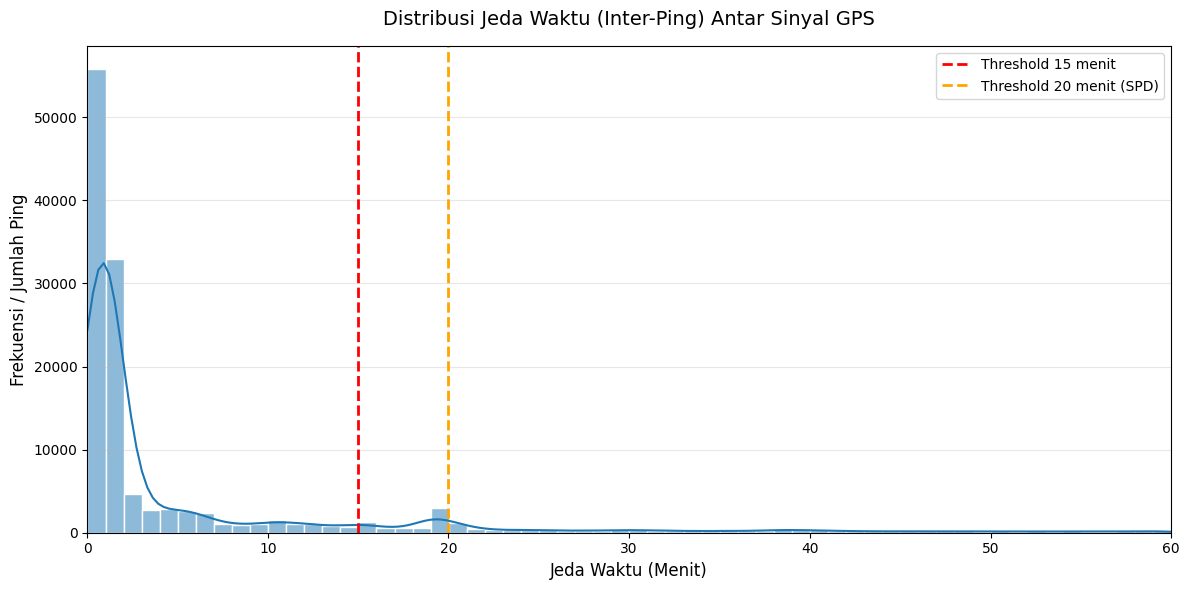

In [15]:
def compute_interping_delta(df: pl.DataFrame, *,
                            max_minutes: float = 60.0) -> np.ndarray:
    """Hitung delta_t (menit) antar ping berurutan per MAID."""
    df_with_dt = (
        df.sort(["maid", "timestamp"])
        .with_columns(
            (pl.col("timestamp").diff().over("maid") / 60).alias("delta_t_min")
        )
        .filter(
            pl.col("delta_t_min").is_not_null()
            & (pl.col("delta_t_min") > 0)
            & (pl.col("delta_t_min") <= max_minutes)
        )
    )
    return df_with_dt["delta_t_min"].to_numpy()


def plot_interping_distribution(deltas: np.ndarray, *,
                                spd_threshold_min: float = 20.0,
                                xmax: float = 60.0) -> None:
    plt.figure(figsize=(12, 6))
    sns.histplot(deltas, bins=60, kde=True,
                 color="#1f77b4", edgecolor="white")
    plt.title("Distribusi Jeda Waktu (Inter-Ping) Antar Sinyal GPS",
              fontsize=14, pad=15)
    plt.xlabel("Jeda Waktu (Menit)", fontsize=12)
    plt.ylabel("Frekuensi / Jumlah Ping", fontsize=12)

    plt.axvline(x=15, color="red", linestyle="--", linewidth=2,
                label="Threshold 15 menit")
    plt.axvline(x=spd_threshold_min, color="orange", linestyle="--", linewidth=2,
                label=f"Threshold {spd_threshold_min:.0f} menit (SPD)")

    plt.xlim(0, xmax)
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


deltas = compute_interping_delta(df_candidates_collapsed, max_minutes=60.0)
plot_interping_distribution(deltas, spd_threshold_min=SPD_TIME_THRESHOLD_MIN)


---

## Stage 2 — Trajectory Segmentation via Stay Point Detection

Implementasi **Zheng et al. 2011 SPD** (dirujuk Li et al. 2025 §3.3.1 sebagai
metode supervised O(N) berbasis dual threshold time + distance).

### Algoritma (per MAID, ping disorting by ts)
```
i = 0
while i < n:
    j = i + 1
    while j < n:
        if haversine(p_i, p_j) > dist_threshold:
            cluster i..j-1
            if (ts_{j-1} - ts_i) >= time_threshold and (j - i >= 2):
                → stay point: tandai i..j-1 as is_stay_point
                trip_id += 1 untuk ping berikutnya
            i = j; break
        j += 1
    else:  # j reach n
        cek cluster i..n-1; same logic
```

### Output
- `trip_id`: integer per MAID, dimulai 0; increment setiap stay point selesai.
- `is_stay_point`: boolean, True jika ping bagian dari cluster stay point.

Trip = ping dengan `is_stay_point=False`, dikelompokkan per `(maid, trip_id)`.

### Threshold default
- `dist = 100 m` — radius klaster (Zheng 2011).
- `time = 20 menit` — durasi minimal untuk qualify stay point (lihat EDA di atas).

In [16]:
def _spd_scan(lat: np.ndarray, lon: np.ndarray, ts: np.ndarray,
              *, dist_thr_m: float, time_thr_s: float
              ) -> tuple[np.ndarray, np.ndarray]:
    """SPD ala Zheng et al. 2011 untuk SATU urutan ping (sudah sorted by ts).

    Returns:
        trip_id : int array — increments setelah cluster stay point selesai
        is_stay : bool array — True jika ping bagian cluster stay point
    """
    n = len(lat)
    trip_id = np.zeros(n, dtype=np.int64)
    is_stay = np.zeros(n, dtype=bool)
    if n == 0:
        return trip_id, is_stay

    current_trip = 0
    i = 0
    while i < n:
        j = i + 1
        broken = False
        while j < n:
            d = haversine_m(lat[i], lon[i], lat[j], lon[j])
            if d > dist_thr_m:
                cluster_size = j - i
                cluster_duration = ts[j - 1] - ts[i]
                if cluster_size >= 2 and cluster_duration >= time_thr_s:
                    is_stay[i:j] = True
                    trip_id[i:j] = current_trip
                    current_trip += 1
                else:
                    trip_id[i:j] = current_trip
                i = j
                broken = True
                break
            j += 1

        if not broken:
            cluster_size = n - i
            cluster_duration = ts[n - 1] - ts[i] if cluster_size >= 2 else 0
            if cluster_size >= 2 and cluster_duration >= time_thr_s:
                is_stay[i:n] = True
                trip_id[i:n] = current_trip
                current_trip += 1
            else:
                trip_id[i:n] = current_trip
            break

    return trip_id, is_stay


def segment_trips(df: pl.DataFrame, *,
                  dist_thr_m: float = SPD_DIST_THRESHOLD_M,
                  time_thr_min: float = SPD_TIME_THRESHOLD_MIN
                  ) -> pl.DataFrame:
    """Tambahkan kolom `trip_id` (per MAID) dan `is_stay_point` ke df.

    Kombinasi (maid, trip_id) jadi key trip global.
    """
    time_thr_s = time_thr_min * 60.0
    df_sorted = df.sort(["maid", "timestamp"])

    n_total = df_sorted.height
    trip_ids = np.empty(n_total, dtype=np.int64)
    is_stay_arr = np.empty(n_total, dtype=bool)

    # Iterate per MAID (partition_by maintain_order untuk konsistensi alignment)
    offset = 0
    for sub in df_sorted.partition_by("maid", maintain_order=True):
        n = sub.height
        lat = sub["latitude"].to_numpy()
        lon = sub["longitude"].to_numpy()
        ts = sub["timestamp"].to_numpy()
        t, s = _spd_scan(lat, lon, ts,
                         dist_thr_m=dist_thr_m, time_thr_s=time_thr_s)
        trip_ids[offset:offset + n] = t
        is_stay_arr[offset:offset + n] = s
        offset += n

    return df_sorted.with_columns([
        pl.Series("trip_id", trip_ids),
        pl.Series("is_stay_point", is_stay_arr),
    ])


def report_segmentation_summary(df_trips: pl.DataFrame) -> None:
    """Print summary: jumlah trip, jumlah stay point, distribusi panjang trip."""
    n_pings = df_trips.height
    n_stay = int(df_trips["is_stay_point"].sum())
    n_moving = n_pings - n_stay

    df_moving = df_trips.filter(~pl.col("is_stay_point"))
    n_trips = df_moving.select(["maid", "trip_id"]).unique().height

    trip_sizes = (
        df_moving.group_by(["maid", "trip_id"])
        .agg(n=pl.len())
        ["n"].to_numpy()
    )

    print("=" * 60)
    print("STAGE 2 — TRAJECTORY SEGMENTATION (SPD)")
    print("=" * 60)
    print(f"Total ping             : {n_pings:>12,}")
    print(f"  - moving (in trip)   : {n_moving:>12,}  ({n_moving/n_pings:.2%})")
    print(f"  - stay point         : {n_stay:>12,}  ({n_stay/n_pings:.2%})")
    print(f"Total trip (moving)    : {n_trips:>12,}")
    if len(trip_sizes) > 0:
        print(f"\nDistribusi panjang trip (ping/trip):")
        print(f"  min / median / mean / max : "
              f"{trip_sizes.min()} / {int(np.median(trip_sizes))} / "
              f"{trip_sizes.mean():.1f} / {trip_sizes.max()}")
        print(f"  p25 / p75 / p95           : "
              f"{int(np.percentile(trip_sizes, 25))} / "
              f"{int(np.percentile(trip_sizes, 75))} / "
              f"{int(np.percentile(trip_sizes, 95))}")


In [17]:
df_trips = segment_trips(
    df_candidates_collapsed,
    dist_thr_m=SPD_DIST_THRESHOLD_M,
    time_thr_min=SPD_TIME_THRESHOLD_MIN,
)

report_segmentation_summary(df_trips)
df_trips.write_parquet(OUTPUT_TRIPS, compression="zstd")
print(f"\nTersimpan: {OUTPUT_TRIPS.resolve()}")


STAGE 2 — TRAJECTORY SEGMENTATION (SPD)
Total ping             :      169,914
  - moving (in trip)   :       96,910  (57.03%)
  - stay point         :       73,004  (42.97%)
Total trip (moving)    :        8,507

Distribusi panjang trip (ping/trip):
  min / median / mean / max : 1 / 5 / 11.4 / 210
  p25 / p75 / p95           : 2 / 13 / 43

Tersimpan: /home/repal/Github/skripsi/server/processed-data/gps_rru_trips.parquet


### Drop short trips + drop singleton MAID

Trip dengan < `MIN_PINGS_PER_TRIP` ping (default 3) tidak bisa dipakai untuk
HMM — minimal butuh start, mid, end untuk estimasi heading & transition.

In [ ]:
# Filter: hanya pertimbangkan ping moving (exclude stay points)
df_trips_moving = df_trips.filter(~pl.col("is_stay_point"))

df_trips_moving = drop_short_trips(
    df_trips_moving,
    min_pings=MIN_PINGS_PER_TRIP,
    label="stage 2b",
)
df_trips_moving = drop_singleton_maids(df_trips_moving, label="stage 2b")


[stage 2b] drop short trip (< 3 ping): 2,479 trip (4,327 ping)
[stage 2b] sisa: 6,028 trip, 92,583 ping
[stage 2b] drop singleton MAID (< 2 ping): 0 maid (0 ping)
[stage 2b] sisa: 4,469 maid, 92,583 ping


statistic,maid,timestamp,latitude,longitude,candidate_edge_keys,candidate_dists,n_points_collapsed,trip_id,is_stay_point
str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""92583""",92583.0,92583.0,92583.0,92583.0,92583.0,92583.0,92583.0,92583.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,1.6446e9,-7.755907,110.388112,null,null,1.208105,0.9369,0.0
"""std""",null,549268.339894,0.005718,0.021902,null,null,0.596316,2.049034,null
"""min""","""00015af9-5af9-793c-eb3c-20478c…",1.6436e9,-7.76741,110.3423,null,null,1.0,0.0,0.0
"""25%""",null,1.6441e9,-7.759807,110.3713,null,null,1.0,0.0,null
"""50%""",null,1.6446e9,-7.758163,110.389656,null,null,1.0,0.0,null
"""75%""",null,1.6451e9,-7.751164,110.404778,null,null,1.0,1.0,null
"""max""","""ffff7b67-eb14-4a8c-bd76-79f0e3…",1.6461e9,-7.74341,110.4318,null,null,11.0,25.0,0.0


In [27]:
trip_ping_counts = (
    df_trips_moving
    .group_by(["maid", "trip_id"])
    .agg(n_pings=pl.len())
)

distribusi_ping_trip = (
    trip_ping_counts
    .group_by("n_pings")
    .agg(jumlah_trip=pl.len())
    .sort("n_pings")
)

print(distribusi_ping_trip)
print(f"Total trip: {trip_ping_counts.height:,}")
print(f"Rata-rata ping/trip: {trip_ping_counts['n_pings'].mean():.2f}")
print(f"Median ping/trip: {trip_ping_counts['n_pings'].median():.0f}")

shape: (141, 2)
┌─────────┬─────────────┐
│ n_pings ┆ jumlah_trip │
│ ---     ┆ ---         │
│ u32     ┆ u32         │
╞═════════╪═════════════╡
│ 3       ┆ 918         │
│ 4       ┆ 687         │
│ 5       ┆ 433         │
│ 6       ┆ 390         │
│ 7       ┆ 338         │
│ …       ┆ …           │
│ 182     ┆ 1           │
│ 186     ┆ 1           │
│ 190     ┆ 1           │
│ 193     ┆ 1           │
│ 210     ┆ 1           │
└─────────┴─────────────┘
Total trip: 6,028
Rata-rata ping/trip: 15.36
Median ping/trip: 8
